<a href="https://colab.research.google.com/github/fitrihayatii02-cloud/Praktikum-ADW---Fitri-Hayati-M0501251043-/blob/main/Tugas_Praktikum_STA1542_Minggu_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PRAKTIKUM ANALISIS DERET WAKTU**  
Nama : Fitri Hayati  
NIM  : M0501251043  

-------------------------------------------------------------------------------


# Kecenderungan dalam Deret Waktu

Misalkan suatu deret waktu memiliki fungsi nilai tengah konstan. Model untuk deret waktu tersebut dapat dituliskan sebagai berikut:

$Y_t=\mu_t+X_t$

dengan $E(X_t)=0$ untuk semua $t$.

## Kecenderungan Linear

Deret dikatakan memiliki kecenderungan linear dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t$

Berikut simulasi deret yang memiliki kecenderungan linear dalam waktu.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

In [91]:
# membangkitkan data waktu dalam bentuk array (misalnya, 100 bulan)
np.random.seed(1043)
n=100
t = np.arange(n)

# Membuat deret dengan kecenderungan linear
beta1 = 0.5 * 43
beta0 = 10 + 43
deret = beta0 + beta1*t

# Menambahkan ingar acak
noise = np.random.normal(scale=2, size=n)  # Noise dengan standar deviasi 2
time_series = deret + noise  # Menggabungkan tren dengan noise

# Membuat DataFrame untuk menyimpan data
df = pd.DataFrame({"Time": pd.date_range(start="2017-01-01", periods=100, freq="M"),
                   "Value": time_series})
df


,Time,Value
0,2017-01-31,54.141507
1,2017-02-28,74.627946
2,2017-03-31,95.286694
3,2017-04-30,114.755431
4,2017-05-31,139.059909
...,...,...
95,2024-12-31,2095.246716
96,2025-01-31,2119.543005
97,2025-02-28,2136.644526
98,2025-03-31,2161.445357


Data yang digunakan merupakan data bangkitan deret waktu sebanyak 100 pengamatan bulanan. Data dibangkitkan dengan membentuk kecenderungan linear menggunakan persamaan $deret=53+21.5t$, kemudian ditambahkan *noise* yang dibangkitkan dari distribusi normal dengan rataan nol dan standar deviasi sebesar 2. Pengamatan dimulai pada Januari 2017 dan disimpan dalam DataFrame dengan variabel Time sebagai indeks waktu dan Value sebagai nilai pengamatan.

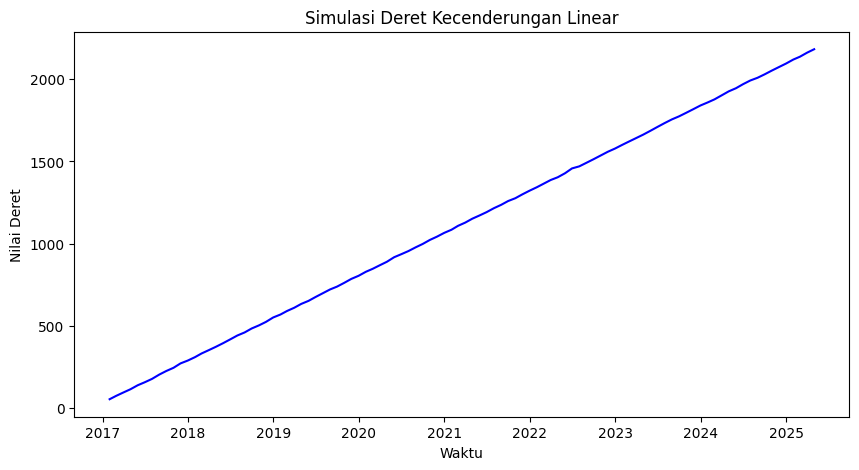

In [90]:
# Plot deret waktu dengan tren linear
plt.figure(figsize=(10, 5))
plt.plot(df["Time"], df["Value"], color="b")
plt.xlabel("Waktu")
plt.ylabel("Nilai Deret")
plt.title("Simulasi Deret Kecenderungan Linear")
plt.show()

Cek apakah ada korelasi antar pengamatan?

**Pemeriksaan Korelasi Antar Pengamatan**  

Untuk mengetahui apakah ada korelasi antar pengamatan, maka dilakukan pemeriksaan autokorelasi. Pemeriksaan pertama dilakukan dengan menghitung autokorelasi pada lag 1 menggunakan fungsi autocorr().

In [6]:
# Mengecek autokorelasi antar pengamatan
autocorrelation = df["Value"].autocorr()

print("Nilai autokorelasi:", autocorrelation)

Nilai autokorelasi: 0.9999976619012944


Berdasarkan hasil output diatas, diperoleh nilai autokorelasi lag ke-1 sebesar 0,999998. Nilai tersebut sangat mendekati 1, yang menunjukkan adanya hubungan positif yang sangat kuat antara nilai pengamatan pada suatu periode dengan nilai pengamatan pada periode sebelumnya.  

Selanjutnya, pemeriksaan dilakukan mengggunakan fungsi *Autocorrelation Function* (ACF), yang bertujuan untuk melihat pola autokorelasi pada beberapa lag.

Lag 0: 1.0000
Lag 1: 0.9700
Lag 2: 0.9400
Lag 3: 0.9101
Lag 4: 0.8801
Lag 5: 0.8503
Lag 6: 0.8204
Lag 7: 0.7906
Lag 8: 0.7610
Lag 9: 0.7315
Lag 10: 0.7019


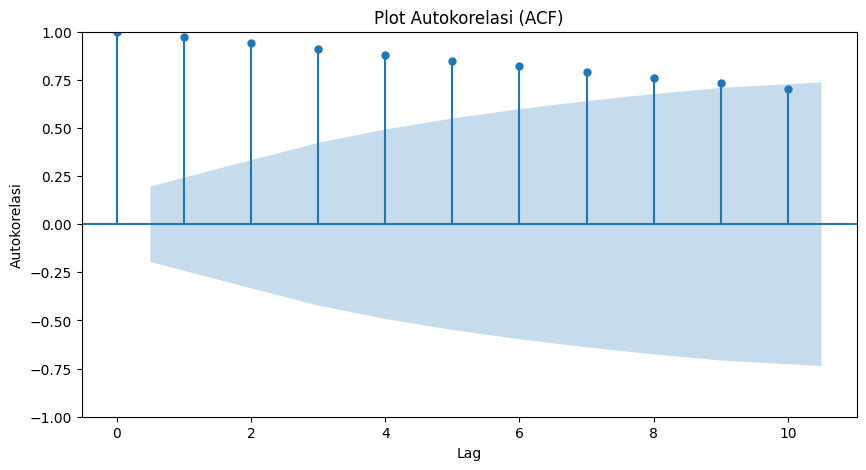

In [8]:
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

# Menghitung nilai ACF hingga lag ke-10
acf_values = acf(df["Value"], nlags=10)

# Menampilkan nilai ACF
for lag, value in enumerate(acf_values):
    print(f"Lag {lag}: {value:.4f}")

# Plot ACF
fig, ax = plt.subplots(figsize=(10, 5))

plot_acf(df["Value"], lags=10, ax=ax)

ax.set_title("Plot Autokorelasi (ACF)")
ax.set_xlabel("Lag")
ax.set_ylabel("Autokorelasi")

plt.show()

Berdasarkan hasil ACF, nilai autokorelasi pada lag ke-1 sebesar 0,9700. Nilai tersebut menunjukkan adanya hubungan positif yang sangat kuat antara pengamatan pada suatu periode dengan pengamatan pada periode sebelumnya. Nilai autokorelasi pada lag ke-2 hingga lag ke-10 juga masih relatif tinggi, meskipun nilainya cenderung menurun seiring bertambahnya lag. Pola tersebut menunjukkan bahwa pengamatan dalam deret waktu memiliki ketergantungan temporal yang kuat.

**Kesimpulan:**  
Berdasarkan hasil pemeriksaan nilai autokorelasi dan Autocorrelation Function (ACF), dapat disimpulkan bahwa terdapat autokorelasi yang kuat antar pengamatan pada data deret waktu yang dibangkitkan. Nilai pengamatan pada suatu periode memiliki keterkaitan dengan nilai pengamatan pada periode-periode sebelumnya.

In [93]:
# Konversi kolom Time menjadi angka (misalnya jumlah bulan sejak periode pertama)
df["Time_Numeric"] = (df["Time"].dt.to_period("M") - df["Time"].dt.to_period("M").min()).apply(lambda x: x.n)

# Hitung korelasi antara Time_Numeric dan Value
correlation = df["Time_Numeric"].corr(df["Value"])

print(f"Nilai korelasi antara Time dan Value: {correlation:.4f}")

Nilai korelasi antara Time dan Value: 1.0000


In [94]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = df["Time_Numeric"]
Y = df["Value"]

#memanggil package statsmodels
import statsmodels.api as sm

# Tambahkan konstanta (intercept) ke model regresi
X = sm.add_constant(X)

# Buat dan jalankan model regresi
model = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.025e+07
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          9.04e-248
Time:                        12:19:51   Log-Likelihood:                -207.15
No. Observations:                 100   AIC:                             418.3
Df Residuals:                      98   BIC:                             423.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           52.4632      0.385    136.237   

Bagaimana hasil pengepasan model regresi dibandingkan dengan nilai parameter asli?  

Berdasarkan hasil pengepasan model regresi, diperoleh persamaan $Y_t = 52.4632 + 21.5122t$. Hasil estimasi tersebut sangat mendekati nilai parameter asli yang digunakan dalam proses pembangkitan data, yaitu $\beta_0 = 53$ dan $\beta_1 = 21.5$. Hal ini menunjukkan bahwa model hasil pengepasan mampu menangkap pola tren linier dengan baik. Adapun perbedaan antara nilai parameter hasil estimasi dan parameter asli disebabkan oleh adanya komponen *noise* pada data yang dibangkitkan.


Apakah model regresi yang dipaskan sudah bagus?  

Model regresi yang dipaskan dapat dikatakan sudah baik karena mampu menghasilkan nilai parameter estimasi yang sangat mendekati nilai parameter asli. Selain itu, berdasarkan hasil output diatas juga terlihat nilai koefisien determinasi (*R-Squared*) sebesar 1.000 yang berarti model mampu menjelaskan seluruh variasi nilai pengamatan. Dengan demikian, model regresi yang dipaskan memiliki kecocokan yang sangat baik terhadap data yang dibangkitkan.

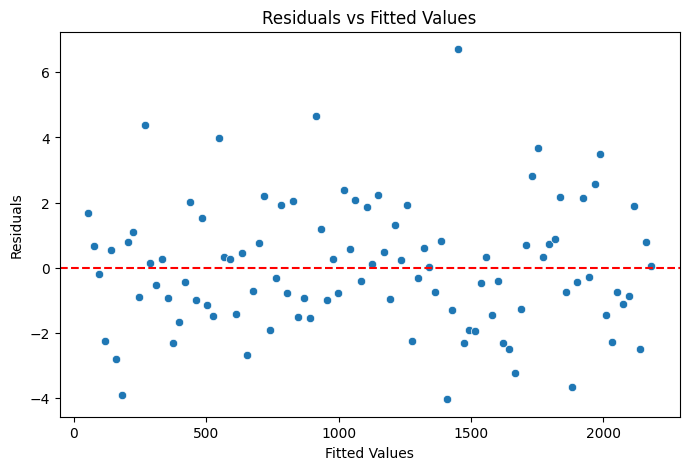

In [95]:
# Analisis Sisaan Model
import seaborn as sns

# Plot Residuals vs. Fitted Values
plt.figure(figsize=(8,5))
sns.scatterplot(x=model.fittedvalues, y=model.resid)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()


Apa interpretasi dari plot tersebut?  

Berdasarkan plot *Residuals vs Fitted Values* diatas, terlihat bahwa nilai sisaan (*residuals*) menyebar secara acak di sekitar garis horizontal nol dan tidak menunjukkan pola tertentu. Hal ini mengindikasi bahwa tidak terdapat pola sistematis pada sisaan dan nilai hasil pengepasan. Dengan demikian, secara visual, model regresi linear yang digunakan telah cukup baik dalam menggambarkan pola hubungan pada data.

In [96]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Uji Breusch-Pagan
bp_test = het_breuschpagan(model.resid, model.model.exog)

print(f"P-value Breusch-Pagan Test: {bp_test[1]:.4f}")


P-value Breusch-Pagan Test: 0.6093


Apa kesimpulan dari nilai uji Breusch Pagan tersebut?

**Hipotesis Breusch–Pagan:**  
$H_0 $= Homoskedastisitas (Varians sisaan bersifat konstan)

$H_1 $= Heteroskedastisitas (Varians sisaan tidak konstan)


Berdasarkan uji Breusch–Pagan diatas, diperoleh nilai *p-value* sebesar 0.6093 lebih besar dari taraf signifikansi 0.05, maka gagal tolak $H_0$. Dengan demikian, dapat disimpulkan bahwa tidak terdapat bukti adanya heteroskedastisitas pada sisaan model.

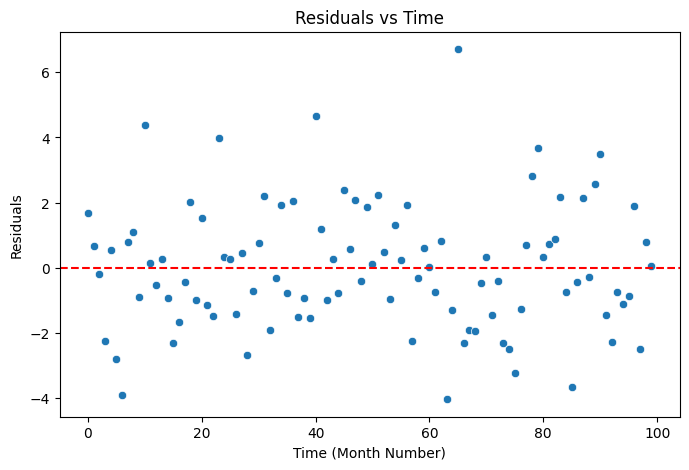

In [97]:
# Plot residual vs time
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Time_Numeric"], y=model.resid)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Time (Month Number)")
plt.ylabel("Residuals")
plt.title("Residuals vs Time")
plt.show()


Berdasarkan plot *Residuals vs Time*, terlihat bahwa nilai sisaan (*residual*) menyebar di sekitar garis horizontal nol sepanjang periode pengamatan dan tidak menunjukkan pola tertentu terdapat waktu. Hal ini menunjukkan bahwa tidak terdapat pola sistematis pada sisaan terhadap waktu.

<Figure size 800x500 with 0 Axes>

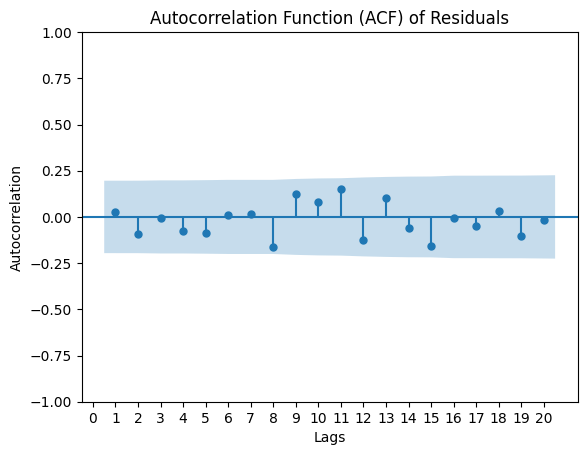

In [98]:
from statsmodels.graphics.tsaplots import plot_acf

# Plot Autocorrelation Function (ACF)
plt.figure(figsize=(8, 5))
plot_acf(model.resid, lags=20, zero=False)
plt.xticks(ticks=range(0, 21, 1))
plt.title("Autocorrelation Function (ACF) of Residuals")
plt.xlabel("Lags")
plt.ylabel("Autocorrelation")
plt.show()


Apa yang dapat Anda simpulkan dari plot di atas?  

Berdasarkan plot *Autocorrelation Function* (ACF) *of Residuals*, seluruh nilai autokorelasi pada lag 1 hingga lag 20 berada di dalam batas interval kepercayaan. Hal ini menunjukkan bahwa tidak terdapat autokorelasi yang signifikan pada sisaan model. Dengan demikian, sisaan tidak menunjukkan pola ketergantungan yang signifikan antarperiode pengamatan, sehingga asumsi independensi sisaan pada model regresi terpenuhi.

In [99]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Uji Ljung-Box untuk autokorelasi residual
ljung_box_test = acorr_ljungbox(model.resid, lags=range(1,20), return_df=True)

print("Ljung-Box Test p-value:")
print(ljung_box_test)

Ljung-Box Test p-value:
      lb_stat  lb_pvalue
1    0.067147   0.795538
2    0.978241   0.613166
3    0.982220   0.805554
4    1.622861   0.804677
5    2.474112   0.780389
6    2.482777   0.870390
7    2.506562   0.926602
8    5.364626   0.717988
9    7.046881   0.632238
10   7.751682   0.653078
11  10.381252   0.496454
12  12.223061   0.427936
13  13.412914   0.416446
14  13.818321   0.463332
15  16.858489   0.327394
16  16.866524   0.394285
17  17.134782   0.445271
18  17.251337   0.505893
19  18.609003   0.482164


Apa kesimpulan dari hasil uji Ljung-Box tersebut?


**Hipotesis Ljung–Box:**  
$H_0 $= Tidak terdapat autokorelasi pada sisaan

$H_1 $= Terdapat autokorelasi pada sisaan

Berdasarkan hasil uji *Ljung–Box*, seluruh nilai *p-value* pada lag 1 hingga lag 19 lebih besar dari taraf signifikansi 0.05. Oleh karena itu, gagal tolak $H_0$ yang menyatakan bahwa tidak terdapat bukti adanya autokorelasi yang signifikan pada sisaan model. Dengan demikian, dapat simpulkan bahwa tidak terdapat bukti bahwa nilai sisaan pada suatu periode memiliki hubungan yang signifikan dengan nilai sisaan pada periode lainnya.

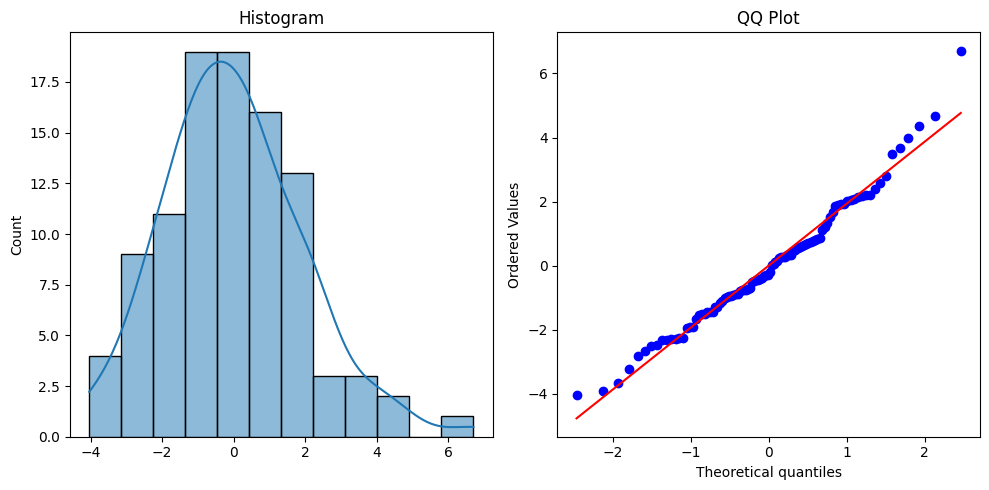

In [100]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(model.resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(model.resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

Apa kesimpulan Anda berdasarkan plot di atas?

Berdasarkan histogram, distribusi sisaan secara umum menunjukkan bentuk yang mendekati distribusi normal, meskipun terdapat sedikit penyimpangan pada bagian ekor. Hal ini juga terlihat pada QQ plot, dimana sebagian besar titik berada di sekitar garis diagonal, meskipun beberapa titik pada bagian ekor menyimpang dari garis. Dengan demikian, dapat disimpulkan bahwa sisaan model secara umum mendekati distribusi normal, meskipun terdapat sedikit penyimpangan dari normalitas pada beberapa pengamatan.

In [101]:
# Uji Shapiro-Wilk
shapiro_stat, shapiro_p_value = stats.shapiro(model.resid)
print(f"Shapiro-Wilk Test: Statistics = {shapiro_stat}, p-value = {shapiro_p_value}")

Shapiro-Wilk Test: Statistics = 0.9784384443815025, p-value = 0.10037738073924857


Apakah kesimpulan Anda dari nilai uji Shapiro Wilk sama dengan kesimpulan Anda berdasarkan plot?

Ya, kesimpulan uji Shapiro–Wilk sama dengan kesimpulan berdasarkan plot.

**Hipotesis Shapiro-Wilk:**  
$H_0 $= Sisaan berdistribusi normal

$H_1 $= Sisaan tidak berdistribusi normal

Berdasarkan plot, distribusi sisaan secara umum terlihat mendekati distribusi normal, meskipun terdapat sedikit penyimpangan pada bagian ekor. Hasil tersebut diperkuat oleh uji Shapiro–Wilk yang menghasilkan *p-value* sebesar 0.1004, lebih besar dari taraf signifikansi 0.05. Oleh karena itu, tidak terdapat bukti yang cukup untuk menyatakan bahwa sisaan tidak berdistribusi normal. Dengan demikian, baik berdasarkan plot maupun berdasarkan uji Shapiro–Wilk, sisaan dapat dianggap memenuhi asumsi normalitas.

## Kecenderungan Kuadratik

Deret dikatakan memiliki kecenderungan kuadratik dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t+\beta_2t^2$


In [103]:
# Menentukan parameter simulasi
np.random.seed(1043)
n_periods = 120
beta_0, beta_1, beta_2 = 50 + 43, 0.5 * 43, 0.02 * 43
noise = np.random.normal(0, 10, n_periods)
time = np.arange(n_periods)

# Membuat komponen kuadratik
quadratic_component = beta_0 + beta_1 * time + beta_2 * time**2

# Menambahkan noise untuk membuat data lebih realistis
data = quadratic_component + noise

# Membuat DataFrame
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')
df_quad = pd.DataFrame({'Date': dates, 'Value': data})

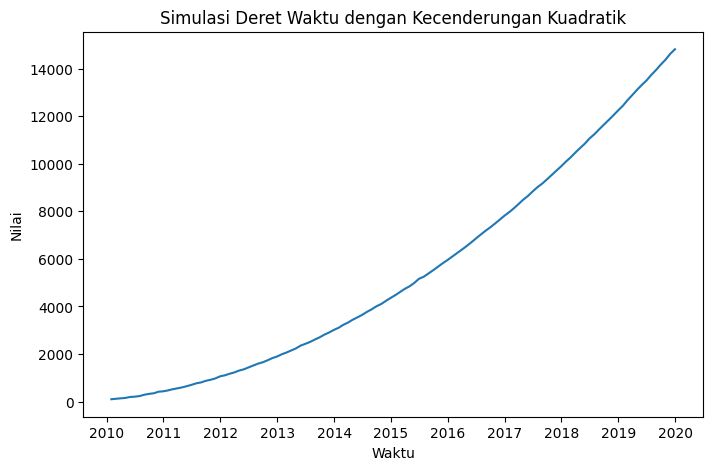

In [105]:
# Plot hasil simulasi deret waktu dengan kecenderungan kuadratik
plt.figure(figsize=(8, 5))
plt.plot(df_quad.Date, df_quad['Value'])
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.show()

In [106]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = np.column_stack((time, time**2))
X = sm.add_constant(X)
Y = data


# Buat dan jalankan model regresi
model_quad = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model_quad.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.179e+07
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          4.96e-311
Time:                        12:33:14   Log-Likelihood:                -443.88
No. Observations:                 120   AIC:                             893.8
Df Residuals:                     117   BIC:                             902.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         88.4379      2.667     33.158      0.0

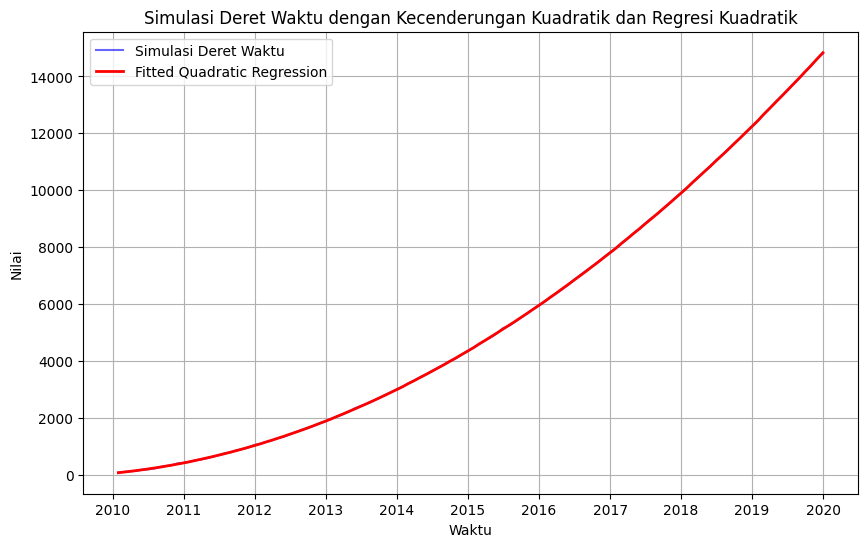

In [107]:
# Prediksi menggunakan model yang sudah dilatih
data_pred = model_quad.predict(X)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(df_quad.Date, df_quad['Value'], label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(df_quad.Date, data_pred, label='Fitted Quadratic Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik dan Regresi Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.legend()
plt.grid(True)
plt.show()

Cek apakah model regresi kuadratik yang dipaskan terhadap sudah memenuhi asumsi!

**Cek Asumsi Model Regresi Kuadratik**

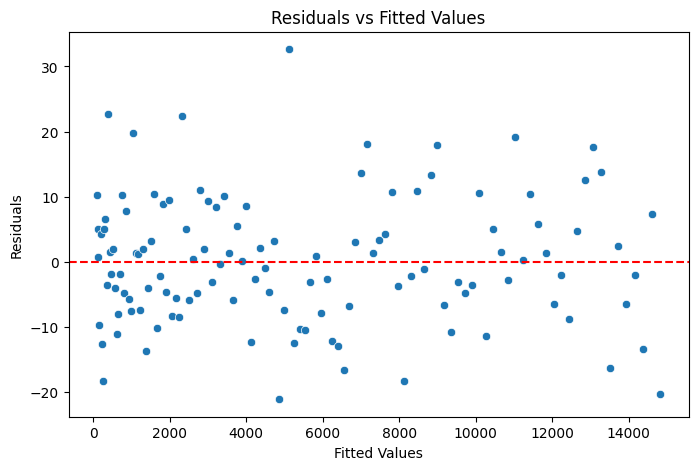

In [108]:
# Plot Residuals vs Fitted Values
plt.figure(figsize=(8, 5))
sns.scatterplot(x=model_quad.fittedvalues, y=model_quad.resid)

plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()


Berdasarkan plot *Residuals vs Fitted Values*, nilai sisaan menyebar secara acak di sekitar garis horizontal nol dan tidak menunjukkan pola tertentu. Hal ini mengindikasi bahwa tidak terdapat pola sistematis pada sisaan terhadap nilai prediksi model. Dengan demikian, model regresi kuadratik telah mampu menggambarkan pola data dengan baik.

In [33]:
# Memeriksa homoskedastisitas
from statsmodels.stats.diagnostic import het_breuschpagan

# Uji Breusch-Pagan
bp_test = het_breuschpagan(model_quad.resid, model_quad.model.exog)

print(f"P-value Breusch-Pagan Test: {bp_test[1]:.4f}")

P-value Breusch-Pagan Test: 0.6445


Berdasarkan uji *Breusch–Pagan*, diperoleh nilai *p-value* sebesar 0.6445 yang lebih besar dari taraf signifikansi 0.05. Oleh karena itu, gagal tolak $H_0$, sehingga tidak terdapat bukti adanya heteroskedastisitas pada sisaan model. Dengan demikian, sisaan model dapat dianggap memiliki varians yang konstan atau memenuhi asumsi homoskedastisitas.

<Figure size 800x500 with 0 Axes>

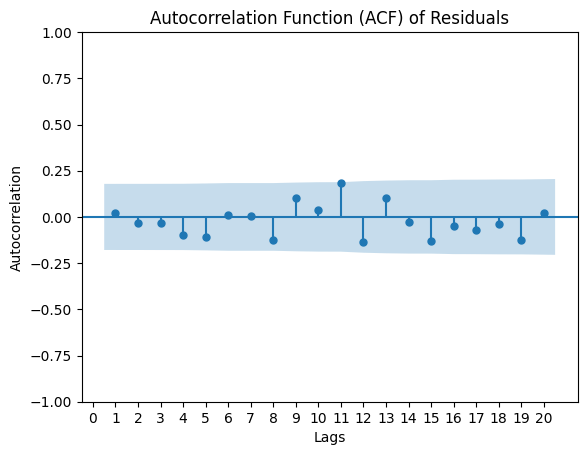

In [109]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(8, 5))

plot_acf(
    model_quad.resid,
    lags=20,
    zero=False
)

plt.xticks(ticks=range(0, 21, 1))
plt.title("Autocorrelation Function (ACF) of Residuals")
plt.xlabel("Lags")
plt.ylabel("Autocorrelation")
plt.show()

Berdasarkan plot *Autocorrelation Function* (ACF) *of Residuals*, seluruh nilai autokorelasi pada lag 1 hingga lag 20 berada di dalam batas interval kepercayaan. Hal ini menunjukkan bahwa tidak terdapat autokorelasi yang signifikan pada sisaan model. Dengan demikian, sisaan tidak menunjukkan pola ketergantungan yang signifikan antarperiode pengamatan, sehingga asumsi independensi sisaan pada model regresi terpenuhi.

In [110]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Uji Ljung-Box
ljung_box_test = acorr_ljungbox(
    model_quad.resid,
    lags=range(1, 20),
    return_df=True
)

print("Ljung-Box Test:")
print(ljung_box_test)

Ljung-Box Test:
      lb_stat  lb_pvalue
1    0.043542   0.834708
2    0.165217   0.920711
3    0.316239   0.956946
4    1.512288   0.824463
5    2.998878   0.700159
6    3.010000   0.807591
7    3.010910   0.883991
8    5.126072   0.744020
9    6.567873   0.682009
10   6.768614   0.747094
11  11.362046   0.413449
12  13.818257   0.312464
13  15.253194   0.291814
14  15.361695   0.353885
15  17.673350   0.280228
16  17.997292   0.324056
17  18.752337   0.342932
18  18.967681   0.393816
19  21.229491   0.324260


Berdasarkan hasil uji *Ljung–Box*, seluruh nilai *p-value* pada lag 1 hingga lag 19 lebih besar dari taraf signifikansi 0.05. Oleh karena itu, gagal tolak $H_0$ yang menyatakan bahwa tidak terdapat bukti adanya autokorelasi yang signifikan pada sisaan model. Dengan demikian, dapat simpulkan bahwa tidak terdapat bukti bahwa nilai sisaan pada suatu periode memiliki hubungan yang signifikan dengan nilai sisaan pada periode lainnya.

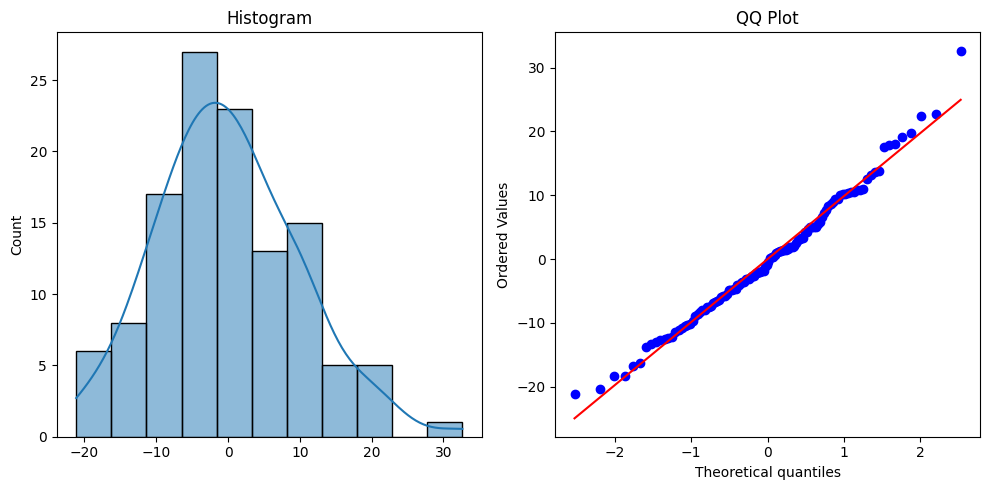

In [111]:
import scipy.stats as stats

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Histogram
sns.histplot(model_quad.resid, kde=True, ax=axes[0])
axes[0].set_title("Histogram")

# QQ Plot
stats.probplot(model_quad.resid, dist="norm", plot=axes[1])
axes[1].set_title("QQ Plot")

plt.tight_layout()
plt.show()

Berdasarkan histogram, distribusi sisaan secara umum menunjukkan bentuk yang mendekati distribusi normal, meskipun terdapat sedikit penyimpangan pada bagian ekor. Hal ini juga terlihat pada QQ plot, dimana sebagian besar titik berada di sekitar garis diagonal, meskipun beberapa titik pada bagian ekor menyimpang dari garis. Dengan demikian, dapat disimpulkan bahwa sisaan model secara umum mendekati distribusi normal, meskipun terdapat sedikit penyimpangan dari normalitas pada beberapa pengamatan.

In [112]:
# Uji Shapiro-Wilk
shapiro_stat, shapiro_p_value = stats.shapiro(model_quad.resid)

print(
    f"Shapiro-Wilk Test Statistic = {shapiro_stat:.4f}, "
    f"p-value = {shapiro_p_value:.4f}"
)

Shapiro-Wilk Test Statistic = 0.9870, p-value = 0.3097


Berdasarkan plot diatas, distribusi sisaan secara umum terlihat mendekati distribusi normal, meskipun terdapat sedikit penyimpangan pada bagian ekor. Hasil tersebut diperkuat oleh uji Shapiro–Wilk yang menghasilkan *p-value* sebesar 0.3097, lebih besar dari taraf signifikansi 0.05. Oleh karena itu, tidak terdapat bukti yang cukup untuk menyatakan bahwa sisaan tidak berdistribusi normal. Dengan demikian, baik berdasarkan plot maupun berdasarkan uji Shapiro–Wilk, sisaan dapat dianggap memenuhi asumsi normalitas.



**Kesimpulan Pemeriksaan Asumsi :**  
Berdasarkan pemeriksaan sisaan, model regresi kuadratik yang dipaskan dapat dikatakan telah memenuhi asumsi yang diperiksa. Sisaan tidak menunjukkan pola sistematis terhadap nilai prediksi, memiliki varians yang relatif konstan, tidak menunjukkan adanya autokorelasi yang signifikan, dan dapat dianggap berdistribusi normal. Dengan demikian, model regresi kuadratik dapat dikatakan sesuai untuk menggambarkan pola data yang dibangkitkan.

## Kecenderungan Musiman/Siklik

Misalkan suatu deret waktu memiliki nilaitengah $\mu_t$ yang didefinisikan sebagai berikut:

$\mu_t=\beta_0+\beta_1 cos(2\pi f t)+\beta_2 sin(2\pi ft)$

Deret tersebut memiliki kecenderungan kosinus yang berpola musiman.

Bentuk lain fungsi nilaitengah dari kecenderungan musiman (misalnya untuk data bulanan) adalah $\mu_t$ berupa suatu konstanta sejumlah 12 yang nilai berbeda-beda. Nilai ini diinterpretasikan sebagai nilai harapan rata-rata data untuk masing-masing bulan, atau dapat dituliskan sebagai berikut:

$\mu_t=\beta_1$ , untuk $t=1,13,25,...$
       
$\mu_t=\beta_2$ , untuk $t=2,14,26,...$

$.$

$.$

$.$

$\mu_t=\beta_{12}$ , $untuk t=12,24,36,...$


In [113]:
# Menentukan parameter simulasi
np.random.seed(1043)
n_periods = 120
beta0, beta1, beta2 = 50 + 43,-25 * 43, -2 * 43
freq=1/12

# Membuat komponen musiman
time = np.arange(n_periods)
seasonal_component = beta0+ beta1*np.cos(2*np.pi*time*freq)+beta2*np.sin(2*np.pi*time*freq)

# Menambahkan noise acak
noise = np.random.normal(0, 2, n_periods)

# Simulasi data dengan hanya komponen musiman dan noise (tanpa tren)
data = seasonal_component + noise

# Membuat index waktu (misalnya menggunakan bulan)
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')

# Membuat DataFrame untuk mempermudah analisis dan visualisasi
df_seasonal = pd.DataFrame({'Date': dates, 'Value': data})


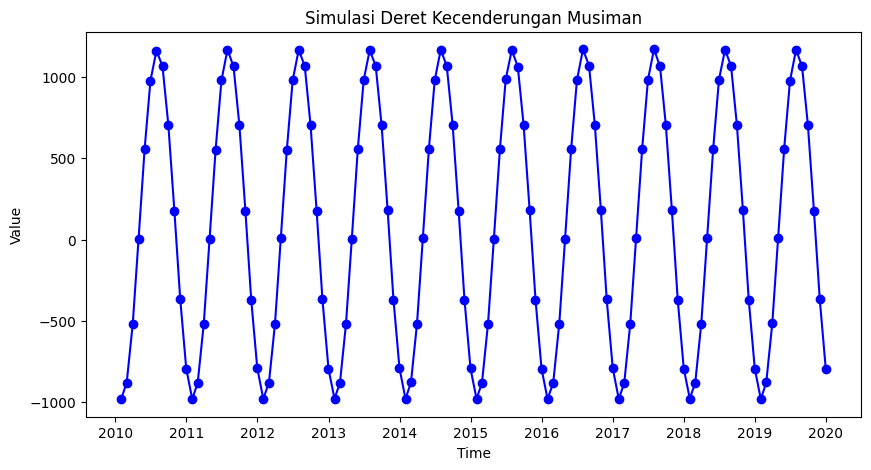

In [114]:
# Plot data deret waktu
plt.figure(figsize=(10, 5))
plt.plot(df_seasonal["Date"], df_seasonal["Value"],'-ob')
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Simulasi Deret Kecenderungan Musiman")
plt.show()


Misalkan deret tersebut merupakan deret musiman dengan periode musiman 12.

In [115]:
# membuat dummy variabel musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
musim= Seasonality(12, initial_period=1).in_sample(df_seasonal.index)
musim.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [116]:
musim

,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
115,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
116,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
117,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
118,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [117]:
# pengepasan model regresi tanpa intercept
musiman=sm.OLS(df_seasonal["Value"],musim).fit()

In [118]:
print(musiman.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.503e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          1.57e-274
Time:                        12:39:59   Log-Likelihood:                -250.40
No. Observations:                 120   AIC:                             524.8
Df Residuals:                     108   BIC:                             558.2
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari     -981.7081      0.650  -1510.515      0.0

Bagaimana interpretasi dari hasil tersebut?


Model Regresi musiman yang di peroleh:

\begin{aligned}
\hat{Y}_t ={}& -981{,}780D_{\text{Januari},t}
-881{,}561D_{\text{Februari},t}
-519{,}918D_{\text{Maret},t} \\
&+6{,}611D_{\text{April},t}
+556{,}182D_{\text{Mei},t}
+981{,}759D_{\text{Juni},t} \\
&+1168{,}475D_{\text{Juli},t}
+1067{,}445D_{\text{Agustus},t}
+704{,}974D_{\text{September},t} \\
&+187{,}613D_{\text{Oktober},t}
-303{,}303D_{\text{November},t}
-794{,}698D_{\text{Desember},t}.
\end{aligned}



dengan $D_{\text{bulan},t}$ merupakan variabel dummy yang bernilai 1 jika pengamatan berada pada bulan tersebut dan bernilai 0 untuk bulan lainnya.

**Interpretasi:**  
Berdasarkan hasil pengepasan model regresi musiman, diperoleh model regresi yang terdiri atas 12 variabel dummy yang merepresentasikan setiap bulan. Karena model dipaskan tanpa menggunakan *intercept*, setiap koefisien secara langsung menunjukkan nilai estimasi rata-rata deret waktu pada bulan yang bersesuaian. Sebagai contoh, nilai estimasi pada bulan Januari adalah sebesar -981.780, sedangkan pada bulan Februari sebesar -881.561 dan pada bulan Maret sebesar -519.918. Nilai estimasi tersebut kemudian mengalami peningkatan hingga mencapai nilai tertinggi pada bulan Juli, yaitu sebesar 11.475, sebelum kembali mengalami penurunan pada bulan-bulan berikutnya. Pola perubahan nilai estimasi antarbulan tersebut menunjukkan adanya pola musiman yang berulang setiap 12 bulan.

Model yang diperoleh memiliki nilai *R-Squared* sebesar 1.000, yang menunjukkan bahwa seluruh variasi nilai deret waktu dapat dijelaskan oleh komponen musiman yang dimasukkan ke dalam model. Selain itu, seluruh koefisien dummy bulan memiliki nilai *p-value* yang sangat kecil < 0,001, sehingga masing-masing koefisien berbeda secara signifikan dari nol pada taraf signifikansi 5%. Dengan demikian, model regresi musiman yang dipaskan mampu menangkap pola musiman pada data dengan sangat baik.



In [119]:
# Analisis Sisaan
# mendapatkan sisaan terbakukan
influence=musiman.get_influence()
std_resid=influence.resid_studentized_internal

mapping={1:'$J$',2:'$F$',3:'$M$',
 4:'$A$',5:'$M$',6:'$J$',
 7:'$J$',8:'$A$',9:'$S$',
 10:'$O$',11:'$N$',12:'$D$'}

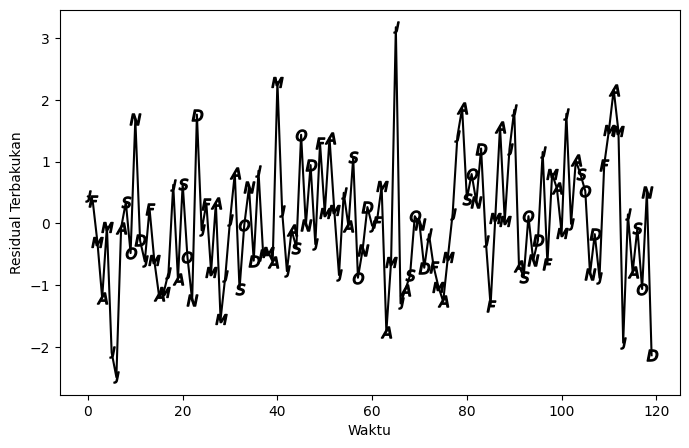

In [120]:
#memetakan sisaan dengan bentuk plot sesuai simbol bulan/musim
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
 plt.plot(i, std_resid[i], marker=mapping[i%12+1],
 color='black', markersize=8)

#membuat plot sisaan terbakukan
plt.plot(std_resid, color='black')
plt.xlabel('Waktu'), plt.ylabel('Residual Terbakukan')
plt.show()


Residual terbakukan terlihat berfluktuasi di sekitar nilai nol sepanjang periode pengamatan. Tidak tampak adanya pola yang sistematis, seperti kecenderungan meningkat atau menurun secara terus-menerus maupun pola berulang yang konsisten dari waktu ke waktu. Meskipun terdapat beberapa sisaan yang relatif ekstrem, baik positif maupun negatif, sebagian besar sisaan masih berada di sekitar nilai nol. Hal ini menunjukkan bahwa setelah komponen musiman dimodelkan, tidak terdapat pola periode waktu yang kuat yang masih tersisa pada sisaan. Dengan demikian, berdasarkan plot sisaan terhadap waktu, model regresi musiman secara umum telah mampu menangkap pola yang terdapat dalam data dengan cukup baik.

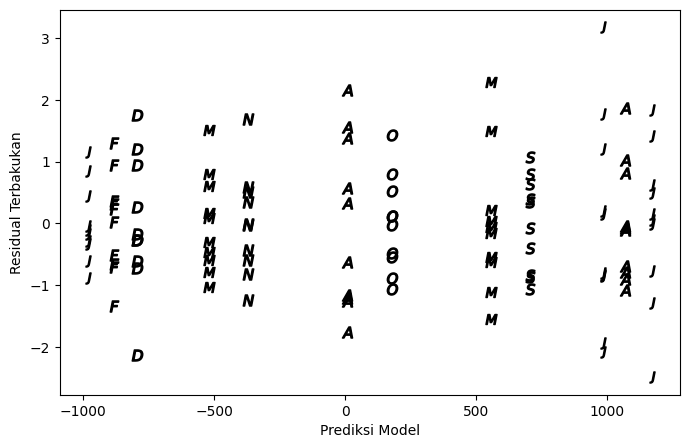

In [122]:
# membuat plot fittedvalues dengan residual terbakukan dengan simbol bulan
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
  plt.plot(musiman.fittedvalues.values[i],
           std_resid[i], marker=mapping[i%12+1],
           color='black', markersize=8)
plt.xlabel('Prediksi Model'),plt.ylabel('Residual Terbakukan')
plt.show()

Residual terbakukan tersebar di sekitar nilai nol pada berbagai nilai prediksi model. Secara umum, tidak terlihat adanya pola sistematis, seperti pola meningkat, menurun, maupun pola melengkung, yang menunjukkan hubungan tertentu antara nilai prediksi model dan sisaan. Hal ini mengindikasikan bahwa model tidak secara sistematis menghasilkan prediksi yang terlalu tinggi atau terlalu rendah pada tingkat nilai prediksi tertentu.

Selain itu, terlihat beberapa kelompok titik yang tersusun secara vertikal. Pola tersebut wajar terjadi karena model regresi musiman menggunakan variabel dummy bulan, sehingga pengamatan yang berasal dari bulan yang sama memiliki nilai prediksi yang sama atau sangat berdekatan. Dengan demikian, berdasarkan plot ini tidak terdapat indikasi kuat adanya pola sistematis antara nilai prediksi model dan sisaan, sehingga model regresi musiman secara umum telah mampu menggambarkan pola data dengan baik.

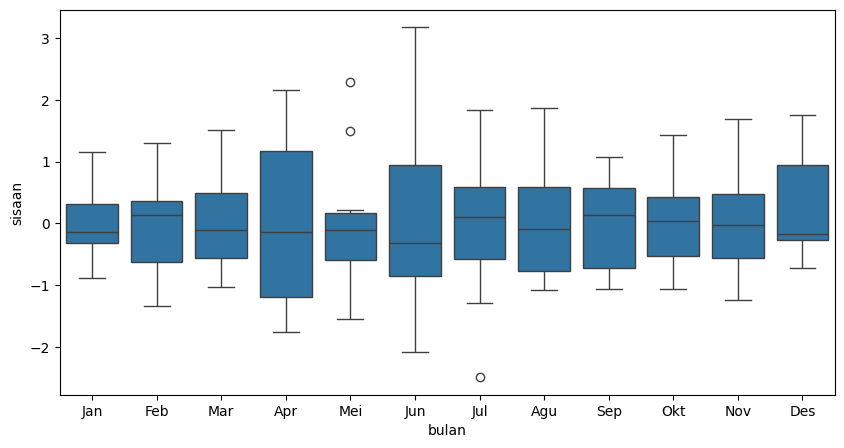

In [58]:
#membuat list daftar bulan
bulan=['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']*10

#membuat dataframe untuk mengidentifikasi sisaan dan periode bulannya
box_sisaan=pd.DataFrame(zip(bulan[:-1], std_resid),
columns=['bulan','sisaan'])

#membuat boxplot per buln
plt.figure(figsize=(10,5))
sns.boxplot(x='bulan',y='sisaan',data=box_sisaan)
plt.show()

Berdasarkan boxplot, median sisaan pada masing-masing bulan secara umum berada di sekitar nilai nol. Hal ini menunjukkan bahwa tidak terdapat bulan tertentu yang secara konsisten menghasilkan sisaan positif atau negatif, sehingga tidak terlihat adanya kecenderungan sisaan yang sistematis antarbulan. Meskipun demikian, tingkat penyebaran sisaan pada beberapa bulan tampak berbeda. Bulan April dan Juni, misalnya, memiliki penyebaran sisaan yang relatif lebih besar dibandingkan bulan lainnya. Selain itu, terdapat beberapa pengamatan yang berada di luar batas whisker dan dapat diidentifikasi sebagai pencilan, terutama pada bulan Mei dan Juli. Namun, secara umum tidak terlihat adanya pola sistematis pada sisaan berdasarkan bulan. Dengan demikian, model regresi musiman yang dipasang secara umum telah mampu menangkap pola musiman utama yang terdapat dalam data.

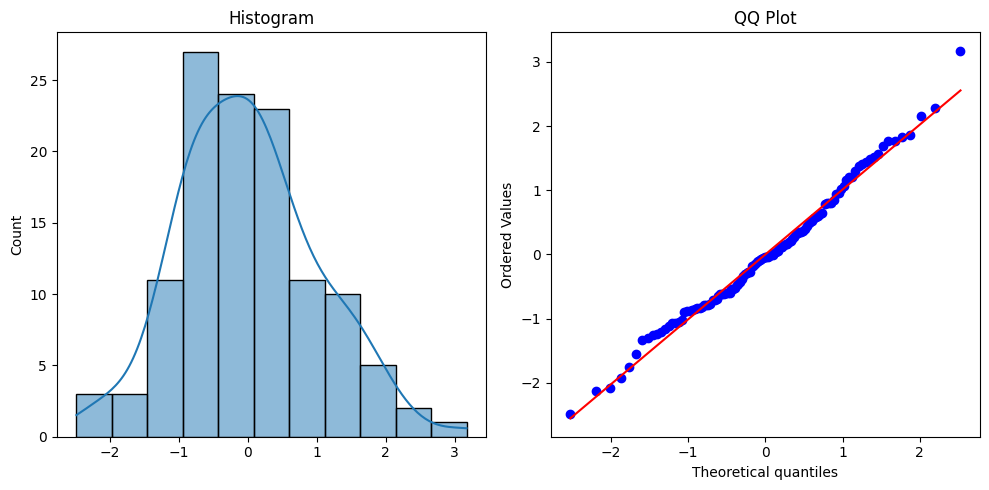

In [124]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(std_resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(std_resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

Berdasarkan histogram, distribusi sisaan terbakukan secara umum menunjukkan bentuk yang mendekati distribusi normal. Sebagian besar sisaan terkonsentrasi di sekitar nilai tengah, meskipun terlihat sedikit penyimpangan pada bagian ekor. Selanjutnya, pada QQ Plot terlihat bahwa sebagian besar titik berada di sekitar dan mengikuti garis diagonal. Meskipun terdapat beberapa titik yang sedikit menyimpang dari garis diagonal, terutama pada bagian ekor kiri dan kanan, penyimpangan tersebut tidak terlihat terlalu besar. Dengan demikian, berdasarkan plot, sisaan terbakukan secara umum dapat dianggap mendekati distribusi normal.

Berdasarkan plot-plot tersebut apakah dapat dikatakan bahwa model yang dipaskan sudah tepat?

Berdasarkan plot-plot yang telah diperoleh, secara visual dapat dikatakan bahwa model regresi musiman yang dipaskan sudah cukup tepat. Sisaan terbakukan terlihat berfluktuasi di sekitar nilai nol dan tidak menunjukkan pola sistematis terhadap waktu maupun nilai prediksi model. Selain itu, boxplot menunjukkan bahwa tidak terdapat bulan tertentu yang secara konsisten memiliki sisaan positif atau negatif. Histogram dan QQ Plot juga menunjukkan bahwa distribusi sisaan secara umum mendekati distribusi normal. Dengan demikian, berdasarkan pemeriksaan visual, model regresi musiman yang dipaskan secara umum telah mampu menggambarkan pola musiman pada data dengan baik.



Hitunglah statistik uji untuk mengecek asumsi model

**Statistik Uji untuk Mengecek Asumsi Model**

In [125]:
#Uji Homoskedastisitas
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm

# Membuat matriks variabel untuk uji Breusch-Pagan
# Gunakan 11 dummy bulan dan tambahkan konstanta
X_bp = sm.add_constant(musim.iloc[:, :-1])

# Uji Breusch-Pagan
bp_test = het_breuschpagan(
    musiman.resid,
    X_bp
)

print("Breusch-Pagan Test")
print("LM Statistic:", bp_test[0])
print("LM p-value:", bp_test[1])
print("F Statistic:", bp_test[2])
print("F p-value:", bp_test[3])

Breusch-Pagan Test
LM Statistic: 20.005802774856352
LM p-value: 0.045261157863283275
F Statistic: 1.96432007569371
F p-value: 0.03896890803535904


Berdasarkan hasil uji Breusch–Pagan, diperoleh LM p-value sebesar 0.04526 dan F p-value sebesar 0.03897. Kedua nilai tersebut lebih kecil daripada taraf signifikansi 0.05, sehingga tolak $H_0$. Dengan demikian, terdapat indikasi bahwa varians sisaan tidak konstan atau mengalami heteroskedastisitas. Oleh karena itu, berdasarkan uji Breusch–Pagan, asumsi homoskedastisitas pada model regresi musiman belum terpenuhi.

In [126]:
#Uji Autokorelasi
from statsmodels.stats.diagnostic import acorr_ljungbox

# Uji Ljung-Box
ljung_box = acorr_ljungbox(
    musiman.resid,
    lags=[12],
    return_df=True
)

print("Ljung-Box Test")
print(ljung_box)

Ljung-Box Test
      lb_stat  lb_pvalue
12  14.408409   0.275392


Berdasarkan hasil uji Ljung–Box pada lag ke-12, diperoleh p-value sebesar 0.2754 yang lebih besar daripada taraf signifikansi 0.05. Oleh karena itu, tidak terdapat bukti yang cukup untuk menyatakan adanya autokorelasi pada sisaan hingga lag ke-12. Dengan demikian, sisaan dapat dianggap tidak memiliki autokorelasi yang signifikan, sehingga asumsi tidak adanya autokorelasi sisaan dapat dianggap terpenuhi.

In [128]:
#Uji Normalitas
from scipy.stats import shapiro

# Uji Shapiro-Wilk
shapiro_test = shapiro(musiman.resid)

print("Shapiro-Wilk Test")
print("Statistic:", shapiro_test.statistic)
print("p-value:", shapiro_test.pvalue)

Shapiro-Wilk Test
Statistic: 0.9888967729992452
p-value: 0.44105146807272144


Berdasarkan hasil uji Shapiro–Wilk, diperoleh p-value sebesar 0.4411 yang lebih besar daripada taraf signifikansi 0.05. Oleh karena itu, tidak terdapat bukti yang cukup untuk menyatakan bahwa sisaan menyimpang dari distribusi normal. Dengan demikian, sisaan dapat dianggap berdistribusi normal sehingga asumsi normalitas sisaan pada model regresi musiman dapat dianggap terpenuhi.

In [129]:
# pengepasan model regresi dengan intersep
musiman_int=sm.OLS(df_seasonal["Value"],sm.add_constant(musim.iloc[:,1:])).fit()

In [130]:
print(musiman_int.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.503e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          1.57e-274
Time:                        13:03:01   Log-Likelihood:                -250.40
No. Observations:                 120   AIC:                             524.8
Df Residuals:                     108   BIC:                             558.2
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -981.7081      0.650  -1510.515      0.0

Perhatikan hasil pengepasan model dengan intersep. Bandingkan hasilnya dengan pengepasan tanpa intersep. Bagaimana interpretasi model dengan intersep?

Model regresi musiman dengan intersep memberikan hasil pengepasan yang ekuivalen dengan model tanpa intersep. Perbedaannya terletak pada interpretasi parameter, dimana pada model dengan intersep bulan Januari digunakan sebagai kategori referensi sehingga nilai intersep menunjukkan nilai estimasi rata-rata pada bulan Januari. Koefisien dummy bulan lainnya menunjukkan perbedaan nilai estimasi bulan tersebut terhadap Januari. Berdasarkan pemeriksaan asumsi, sisaan memenuhi asumsi normalitas dan tidak menunjukkan autokorelasi yang signifikan. Namun, berdasarkan uji Breusch–Pagan, masih terdapat indikasi heteroskedastisitas. Oleh karena itu, model secara umum telah menangkap pola musiman dengan baik, tetapi asumsi homoskedastisitas belum sepenuhnya terpenuhi.  


Apakah model dengan intersep sudah memenuhi asumsi regresi?

**Uji Asumsi Model dengan Intersep**

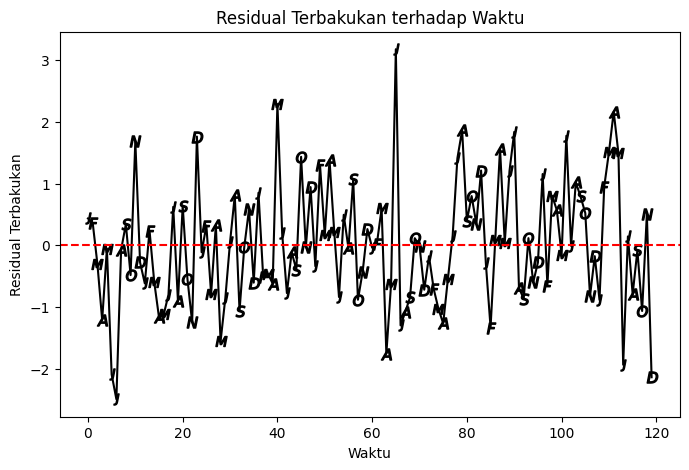

In [131]:
# Mendapatkan sisaan terbakukan
influence_int = musiman_int.get_influence()
std_resid_int = influence_int.resid_studentized_internal

# Plot sisaan terbakukan terhadap waktu
plt.figure(figsize=(8, 5))

for i in range(len(std_resid_int)):
    plt.plot(
        i,
        std_resid_int[i],
        marker=mapping[i % 12 + 1],
        color='black',
        markersize=8
    )

plt.plot(std_resid_int, color='black')

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel('Waktu')
plt.ylabel('Residual Terbakukan')
plt.title('Residual Terbakukan terhadap Waktu')

plt.show()

Sisaan tidak menunjukkan pola sistematis terhadap waktu dan secara umum berfluktuasi secara acak di sekitar nol. Oleh karena itu, berdasarkan pemeriksaan visual, tidak terdapat indikasi kuat bahwa masih terdapat pola antarwaktu yang belum dapat dijelaskan oleh model regresi musiman dengan intersep.

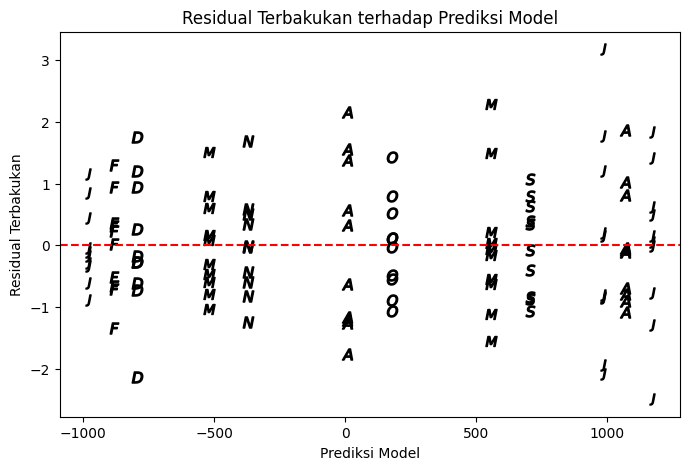

In [132]:
# Plot fitted values terhadap sisaan terbakukan
plt.figure(figsize=(8, 5))

for i in range(len(std_resid_int)):
    plt.plot(
        musiman_int.fittedvalues.values[i],
        std_resid_int[i],
        marker=mapping[i % 12 + 1],
        color='black',
        markersize=8
    )

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel('Prediksi Model')
plt.ylabel('Residual Terbakukan')
plt.title('Residual Terbakukan terhadap Prediksi Model')

plt.show()

Berdasarkan plot residual terbakukan terhadap nilai prediksi model, sisaan tersebar secara acak di sekitar garis nol dan tidak menunjukkan pola sistematis terhadap nilai prediksi. Hal ini mengindikasikan bahwa secara visual bentuk hubungan yang dimodelkan telah cukup sesuai dan tidak terdapat pola nonlinier yang jelas yang belum ditangkap oleh model.

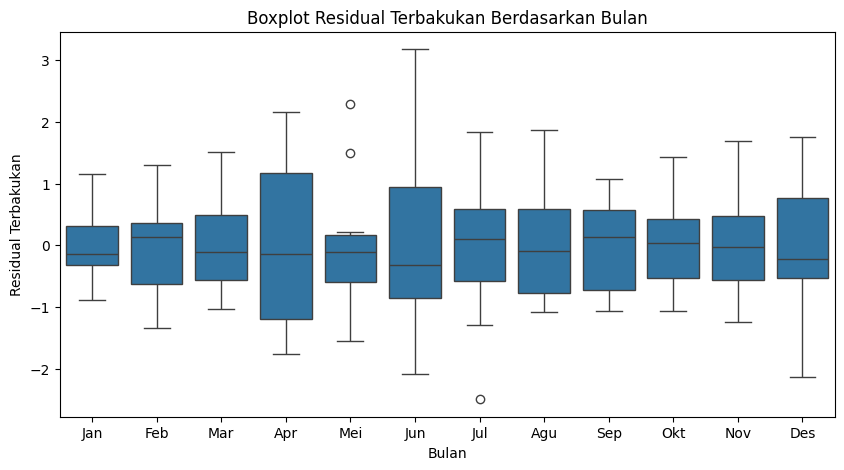

In [133]:
# Membuat daftar bulan
bulan = [
    'Jan', 'Feb', 'Mar', 'Apr',
    'Mei', 'Jun', 'Jul', 'Agu',
    'Sep', 'Okt', 'Nov', 'Des'
] * 10

# Membuat DataFrame sisaan berdasarkan bulan
box_sisaan_int = pd.DataFrame({
    'bulan': bulan,
    'sisaan': std_resid_int
})

# Membuat boxplot sisaan per bulan
plt.figure(figsize=(10, 5))

sns.boxplot(
    x='bulan',
    y='sisaan',
    data=box_sisaan_int
)

plt.xlabel('Bulan')
plt.ylabel('Residual Terbakukan')
plt.title('Boxplot Residual Terbakukan Berdasarkan Bulan')

plt.show()

Berdasarkan boxplot residual terbakukan berdasarkan bulan, sisaan pada setiap bulan secara umum berpusat di sekitar nilai nol. Hal ini menunjukkan bahwa setelah komponen musiman dimodelkan menggunakan variabel dummy bulan, tidak terdapat bulan tertentu yang secara konsisten menghasilkan sisaan positif atau negatif. Meskipun demikian, terlihat bahwa tingkat penyebaran sisaan berbeda antarbulan, dengan beberapa bulan, seperti April dan Juni, memiliki penyebaran sisaan yang relatif lebih besar dibandingkan bulan lainnya. Selain itu, terdapat beberapa pengamatan yang berada di luar rentang utama data dan dapat diidentifikasi sebagai pencilan. Namun, secara umum tidak terlihat adanya pola sistematis pada sisaan berdasarkan bulan. Dengan demikian, model regresi musiman tanpa intersep secara umum telah mampu menangkap pola musiman utama yang terdapat dalam data dengan baik.

In [134]:
# Uji Homoskedastisitas
from statsmodels.stats.diagnostic import het_breuschpagan

# Uji Breusch-Pagan
bp_test_int = het_breuschpagan(
    musiman_int.resid,
    musiman_int.model.exog
)

print("Breusch-Pagan Test")
print("LM Statistic:", bp_test_int[0])
print("LM p-value:", bp_test_int[1])
print("F Statistic:", bp_test_int[2])
print("F p-value:", bp_test_int[3])

Breusch-Pagan Test
LM Statistic: 20.0058027748561
LM p-value: 0.045261157863286654
F Statistic: 1.9643200756936812
F p-value: 0.03896890803536267


Berdasarkan hasil uji Breusch–Pagan, diperoleh LM p-value sebesar 0.04526 dan F p-value sebesar 0.03897. Kedua nilai p-value lebih kecil daripada taraf signifikansi 0.05, sehingga $H_0$ ditolak. Dengan demikian, terdapat bukti bahwa varians sisaan tidak konstan atau terjadi heteroskedastisitas. Oleh karena itu, asumsi homoskedastisitas pada model regresi musiman dengan intersep belum terpenuhi.

In [135]:
#Uji Autokorelasi
from statsmodels.stats.diagnostic import acorr_ljungbox

# Uji Ljung-Box
ljung_box_int = acorr_ljungbox(
    musiman_int.resid,
    lags=[12],
    return_df=True
)

print("Ljung-Box Test")
print(ljung_box_int)

Ljung-Box Test
      lb_stat  lb_pvalue
12  14.408409   0.275392


Berdasarkan hasil uji Ljung–Box pada lag ke-12, diperoleh p-value sebesar 0.2754 yang lebih besar daripada taraf signifikansi 0.05. Oleh karena itu, tidak terdapat bukti yang cukup untuk menyatakan adanya autokorelasi yang signifikan pada sisaan hingga lag ke-12. Dengan demikian, asumsi tidak adanya autokorelasi atau independensi sisaan pada model regresi musiman dengan intersep dapat dianggap terpenuhi.

In [136]:
#Uji Normalitas
from scipy.stats import shapiro

# Uji Shapiro-Wilk
shapiro_test_int = shapiro(
    musiman_int.resid
)

print("Shapiro-Wilk Test")
print("Statistic:", shapiro_test_int.statistic)
print("p-value:", shapiro_test_int.pvalue)

Shapiro-Wilk Test
Statistic: 0.9888967729992504
p-value: 0.44105146807313056


Berdasarkan hasil uji Shapiro–Wilk, diperoleh p-value sebesar 0.4415 yang lebih besar daripada taraf signifikansi 0.05. Oleh karena itu, tidak terdapat bukti yang cukup untuk menyatakan bahwa sisaan menyimpang dari distribusi normal. Dengan demikian, sisaan pada model regresi musiman dengan intersep dapat dianggap berdistribusi normal, sehingga asumsi normalitas sisaan dapat dianggap terpenuhi.

**Kesimpulan:**  
Berdasarkan hasil pengujian asumsi, model regresi musiman dengan intersep belum sepenuhnya memenuhi seluruh asumsi regresi. Meskipun sisaan tidak menunjukkan pola sistematis yang jelas, tidak terdapat autokorelasi yang signifikan, dan sisaan dapat dianggap berdistribusi normal, hasil uji Breusch–Pagan menunjukkan adanya heteroskedastisitas. Oleh karena itu, asumsi homoskedastisitas belum terpenuhi.

## Kecenderungan Linear dan Musiman

In [150]:
# Parameter
np.random.seed(1043)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 0.5 * 43, 10 * 43 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=2, size=n)

# Gabungan semua komponen
series = trend + seasonality + noise


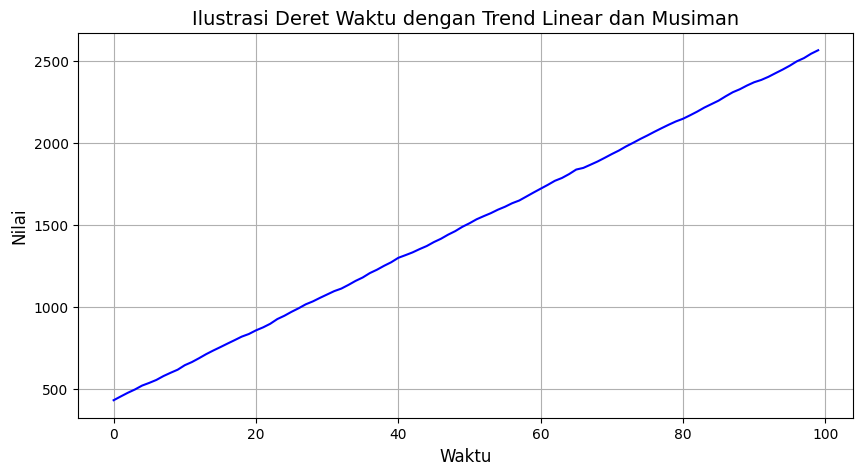

In [151]:
plt.figure(figsize=(10, 5))
plt.plot(x, series, color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman', fontsize=14)
plt.grid()
plt.show()

Untuk deret tersebut, dibutuhkan model yang mampu menangkap kecenderungan linear (tren) sekaligus kecenderungan musiman dalam deret. Salah satu model sederhana yang dapat digunakan adalah model regresi linear dengan variabel musiman.

In [142]:
# mengubah data menjadi format dataframe
df_mix = pd.DataFrame(series, columns=['Value'])

# mengekstrak komponen musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
season= Seasonality(12, initial_period=1).in_sample(df_mix.index)
season.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [143]:
season['period']=x

model_mix=sm.OLS(series,season).fit()

In [144]:
print(model_mix.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 8.379e+05
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          1.05e-214
Time:                        13:11:35   Log-Likelihood:                -202.12
No. Observations:                 100   AIC:                             430.2
Df Residuals:                      87   BIC:                             464.1
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari      429.8923      0.730    589.135      0.0

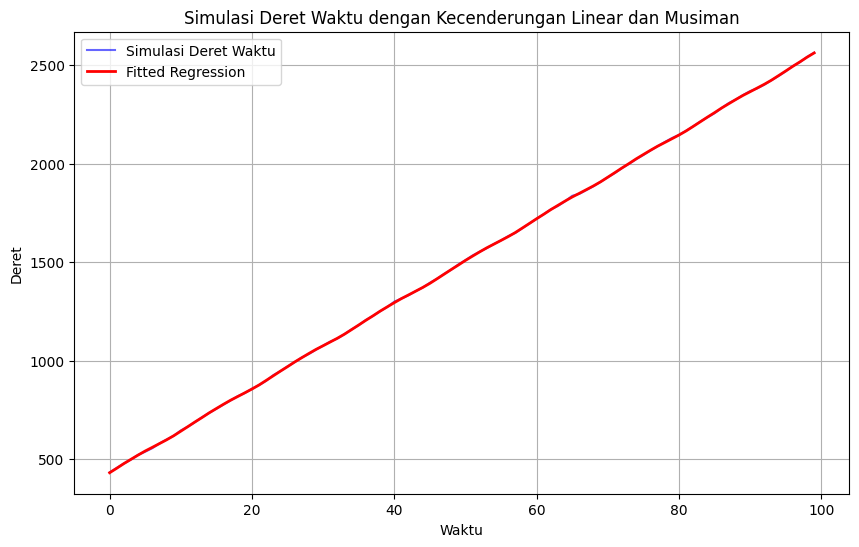

In [146]:
# Prediksi menggunakan model yang sudah dilatih
pred_mix = model_mix.predict(season)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(x, series, label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(x, pred_mix, label='Fitted Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Linear dan Musiman')
plt.xlabel('Waktu')
plt.ylabel('Deret')
plt.legend()
plt.grid(True)
plt.show()

Lakukan pengecekan asumsi model!

**Uji Asumsi Model**

In [152]:
# Residual model
residual = model_mix.resid

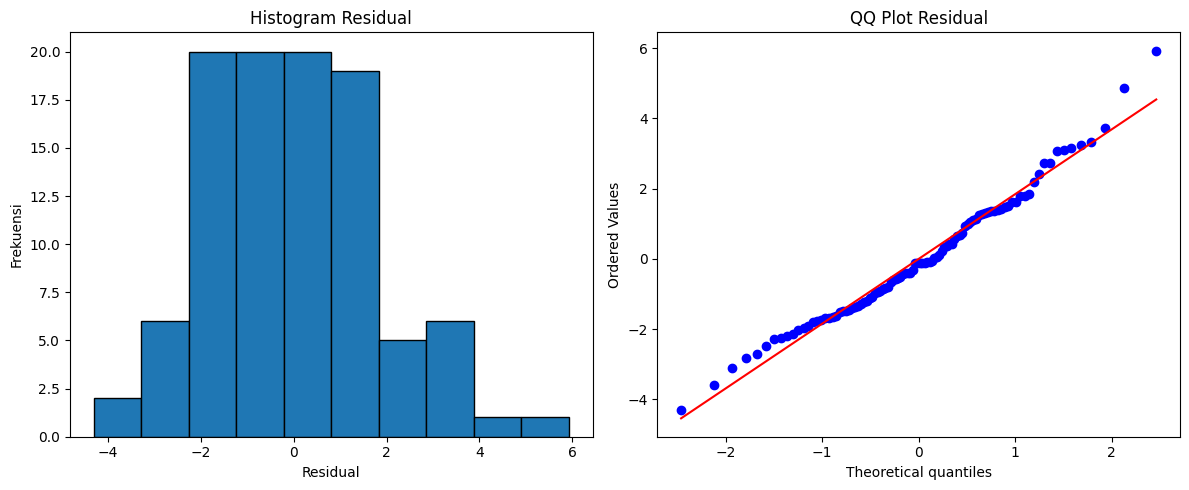

In [153]:
import matplotlib.pyplot as plt
import scipy.stats as stats

plt.figure(figsize=(12, 5))

# Histogram
plt.subplot(1, 2, 1)
plt.hist(residual, bins=10, edgecolor='black')
plt.title('Histogram Residual')
plt.xlabel('Residual')
plt.ylabel('Frekuensi')

# QQ Plot
plt.subplot(1, 2, 2)
stats.probplot(residual, dist="norm", plot=plt)
plt.title('QQ Plot Residual')

plt.tight_layout()
plt.show()

Berdasarkan histogram residual, distribusi residual secara umum berpusat di sekitar nilai nol dan menunjukkan bentuk yang mendekati distribusi normal. Namun, terlihat bahwa distribusi residual memiliki beberapa nilai ekstrem, terutama pada bagian ekor kiri dan kanan. Hal tersebut juga terlihat pada QQ Plot, di mana sebagian besar titik pada bagian tengah berada cukup dekat dengan garis diagonal. Meskipun demikian, terdapat beberapa penyimpangan yang cukup terlihat pada bagian ekor, terutama pada ekor kanan. Dengan demikian, secara visual residual dapat dikatakan mendekati distribusi normal, tetapi terdapat indikasi adanya beberapa nilai ekstrem yang menyebabkan penyimpangan dari normalitas pada bagian ekor distribusi. Oleh karena itu, untuk memperoleh kesimpulan yang lebih objektif, pemeriksaan normalitas perlu dilanjutkan menggunakan uji statistik, seperti uji Shapiro–Wilk.

In [154]:
from scipy.stats import shapiro

stat, p_value = shapiro(residual)

print("Uji Shapiro-Wilk")
print("Statistik =", stat)
print("p-value =", p_value)

if p_value > 0.05:
    print("Kesimpulan: Tidak terdapat cukup bukti untuk menolak asumsi normalitas residual.")
else:
    print("Kesimpulan: Residual tidak berdistribusi normal.")

Uji Shapiro-Wilk
Statistik = 0.9810564366245512
p-value = 0.16053998814920373
Kesimpulan: Tidak terdapat cukup bukti untuk menolak asumsi normalitas residual.


Berdasarkan uji Shapiro–Wilk, diperoleh nilai statistik sebesar 0.9811 dengan p-value sebesar 0.1605. Pada taraf signifikansi 5%, nilai p-value lebih besar daripada 0.05 sehingga gagal menolak hipotesis nol. Dengan demikian, tidak terdapat bukti yang cukup untuk menyatakan bahwa residual menyimpang dari distribusi normal. Hasil ini sejalan dengan pemeriksaan visual melalui histogram dan QQ Plot, di mana sebagian besar residual menunjukkan pola yang mendekati distribusi normal meskipun terdapat beberapa penyimpangan pada bagian ekor. Oleh karena itu, asumsi normalitas residual secara umum dapat dianggap terpenuhi.

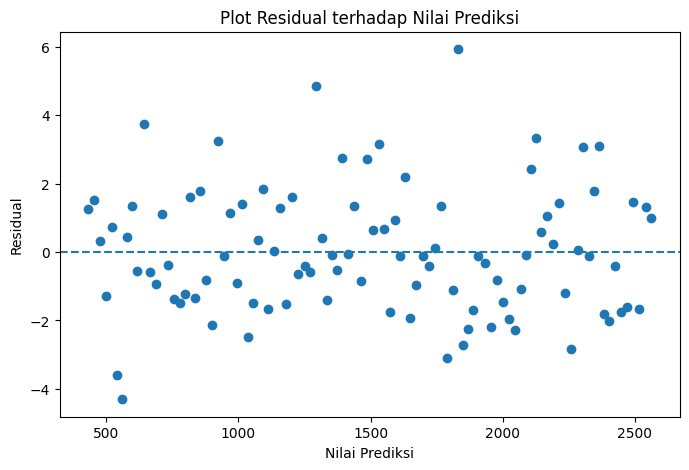

In [155]:
#Uji Homoskedastisitas
fitted = model_mix.fittedvalues

plt.figure(figsize=(8, 5))
plt.scatter(fitted, residual)
plt.axhline(y=0, linestyle='--')
plt.xlabel('Nilai Prediksi')
plt.ylabel('Residual')
plt.title('Plot Residual terhadap Nilai Prediksi')
plt.show()

Berdasarkan plot residual terhadap nilai prediksi, residual tersebar secara acak di sekitar garis horizontal nol dan tidak membentuk pola tertentu. Hal ini menunjukkan bahwa model telah cukup sesuai dalam menangkap pola hubungan pada data. Varians residual juga secara umum tampak relatif konstan, meskipun terdapat beberapa pengamatan dengan residual yang cukup ekstrem. Dengan demikian, secara visual tidak terdapat indikasi kuat pelanggaran asumsi homoskedastisitas.

In [158]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

# Tambahkan konstanta untuk keperluan uji Breusch-Pagan
X_bp = sm.add_constant(model_mix.model.exog)

# Uji Breusch-Pagan
bp_test = het_breuschpagan(
    model_mix.resid,
    X_bp
)

print("Uji Breusch-Pagan")
print("LM Statistic =", bp_test[0])
print("LM p-value =", bp_test[1])
print("F Statistic =", bp_test[2])
print("F p-value =", bp_test[3])

Uji Breusch-Pagan
LM Statistic = 12.193006594380263
LM p-value = 0.51188442154199
F Statistic = 1.0067455265311391
F p-value = 0.44991514181115244


Berdasarkan uji Breusch–Pagan, diperoleh nilai p-value sebesar 0.5119 untuk statistik LM dan 0.4500 untuk statistik F. Kedua nilai p-value tersebut lebih besar dari taraf signifikansi 0.05. Oleh karena itu, gagal tolak $H_0$ yang menyatakan bahwa varians residual bersifat konstan (homoskedastis). Dengan demikian, tidak terdapat bukti yang cukup untuk menyatakan adanya heteroskedastisitas pada model. Oleh karena itu, asumsi homoskedastisitas pada model regresi dapat dianggap terpenuhi.

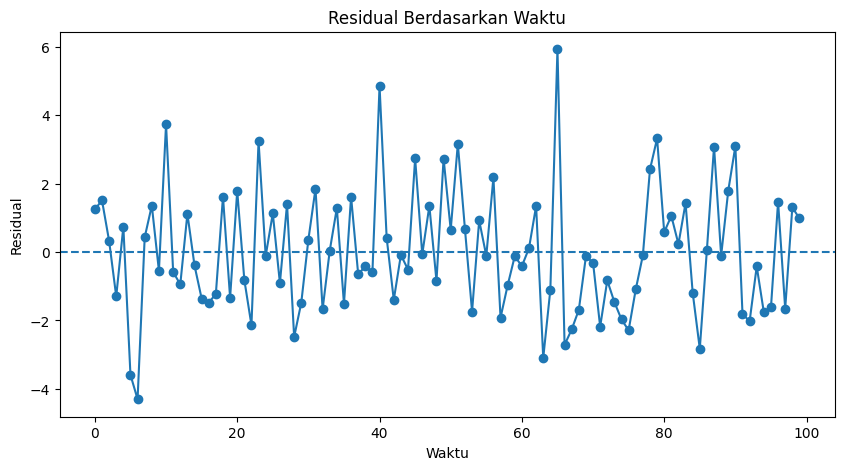

In [159]:
#Uji Autokorelasi
plt.figure(figsize=(10, 5))

plt.plot(x, residual, marker='o')
plt.axhline(y=0, linestyle='--')

plt.xlabel('Waktu')
plt.ylabel('Residual')
plt.title('Residual Berdasarkan Waktu')

plt.show()

Berdasarkan plot residual terhadap waktu, residual secara umum berfluktuasi di sekitar garis nol dan tidak menunjukkan pola yang sistematis, seperti kecenderungan meningkat atau menurun secara terus-menerus maupun pola siklus yang jelas. Meskipun terdapat beberapa residual dengan nilai yang cukup ekstrem, baik positif maupun negatif, penyebaran residual secara umum tampak acak sepanjang waktu. Dengan demikian, secara visual tidak terdapat indikasi kuat adanya autokorelasi residual.

In [160]:
from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(residual)

print("Durbin-Watson =", dw)

Durbin-Watson = 2.0125628029422646


Nilai statistik Durbin–Watson yang diperoleh adalah sebesar 2.0163. Nilai Durbin–Watson yang mendekati 2 mengindikasikan bahwa tidak terdapat autokorelasi orde pertama yang signifikan pada residual. Oleh karena itu, berdasarkan nilai Durbin–Watson tersebut, dapat disimpulkan bahwa asumsi independensi residual atau tidak adanya autokorelasi secara umum dapat dianggap terpenuhi.

Saat melihat plot dari suatu deret, terkadang kita tidak yakin komponen apa saja yang ada dalam deret. Misalkan, apakah deret tidak memuat tren? apakah ada tren? apakah ada komponen musiman? Untuk memastikan komponen apa saja yang ada dalam suatu deret, dapat dilakukan dengan dekomposisi deret. Dekomposisi deret bertujuan menguraikan deret menjadi 3 komponen, yaitu tren, musiman, dan noise.

In [ ]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(df['Value'], model='additive', period=12)

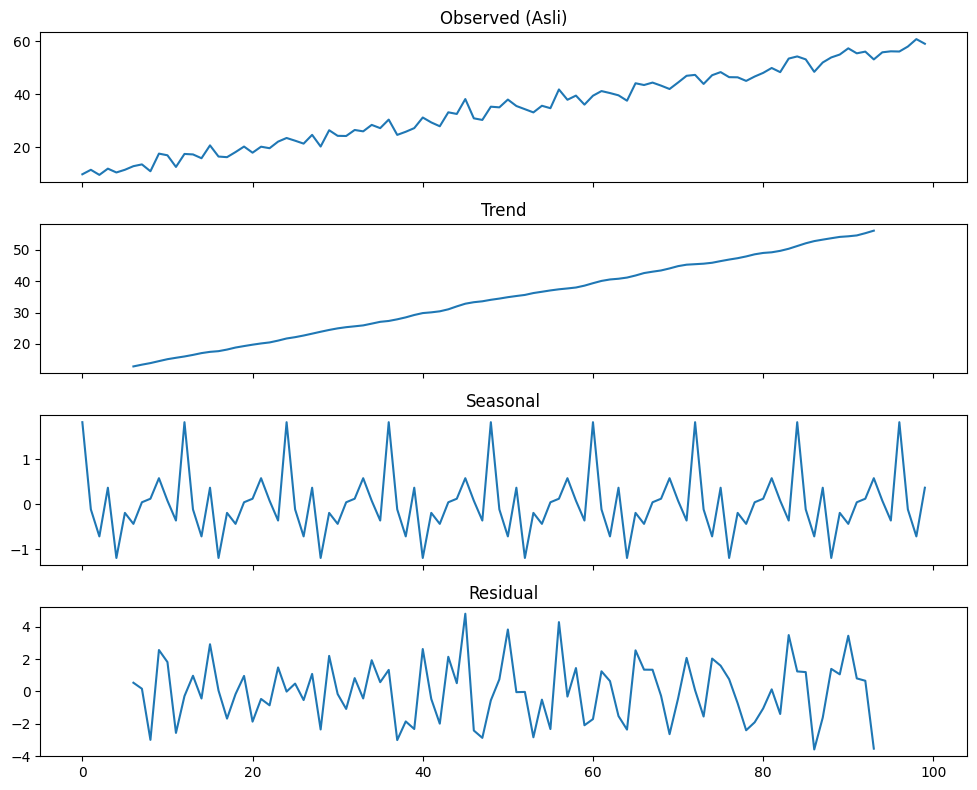

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana interpretasi hasil dekomposisi deret tersebut?

Berdasarkan hasil dekomposisi deret waktu, dapat diinterpretasikan bahwa deret yang diamati terdiri atas komponen tren, musiman, dan residual.
- **Komponen tren** menunjukkan kecenderungan nilai deret yang terus meningkat seiring waktu. Hal ini menunjukkan adanya kecenderungan jangka panjang yang positif pada data.
- **Komponen musiman** menunjukkan pola fluktuasi yang berulang secara relatif konsisten sepanjang periode pengamatan. Hal ini mengindikasikan adanya unsur musiman dalam deret.
- **Komponen residual** menunjukkan variasi yang masih tersisa setelah pengaruh tren dan musiman dipisahkan dari data. Residual berfluktuasi di sekitar nilai nol dan merepresentasikan bagian variasi deret yang tidak dapat dijelaskan oleh kedua komponen tersebut.

Dengan demikian, hasil dekomposisi menunjukkan bahwa variasi pada deret waktu dapat dijelaskan oleh adanya kecenderungan meningkat (tren) dan pola musiman, sedangkan variasi yang tidak dapat dijelaskan oleh kedua komponen tersebut tercermin dalam residual.

In [163]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear dan musiman
from statsmodels.tsa.seasonal import seasonal_decompose
result_mix = seasonal_decompose(df_mix['Value'], model='additive', period=12)

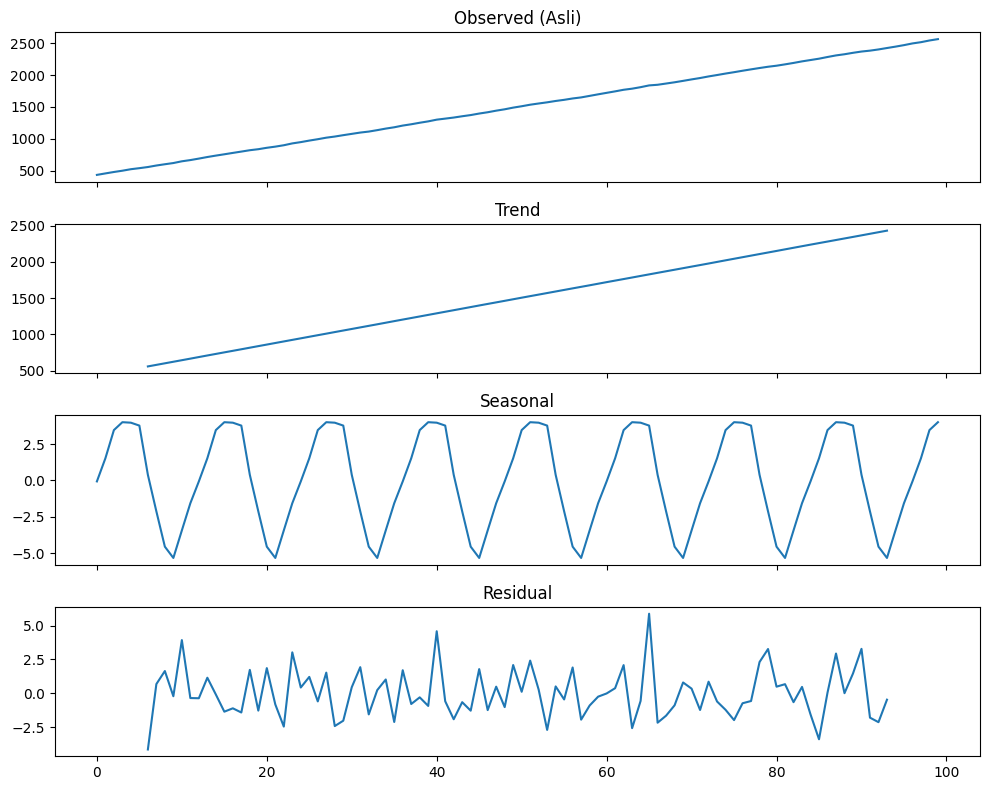

In [164]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result_mix.observed.plot(ax=axes[0], title='Observed (Asli)')
result_mix.trend.plot(ax=axes[1], title='Trend')
result_mix.seasonal.plot(ax=axes[2], title='Seasonal')
result_mix.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()


Bagaimana interpretasi hasil dekomposisi deret tersebut?

Berdasarkan hasil dekomposisi deret waktu tersebut, interpretasinya dapat dijelaskan sebagai berikut.
- **Komponen observed (data asli)** menunjukkan bahwa nilai deret waktu secara umum terus meningkat dari awal hingga akhir periode pengamatan. Meskipun terdapat sedikit variasi pada beberapa waktu, pola utama data memperlihatkan kecenderungan peningkatan yang cukup kuat.
- **Komponen trend** menunjukkan pola yang terus meningkat secara hampir linear. Hal ini mengindikasikan bahwa deret waktu memiliki kecenderungan jangka panjang yang positif, yaitu nilai deret cenderung meningkat seiring bertambahnya waktu.
- **Komponen seasonal** memperlihatkan pola fluktuasi yang berulang secara teratur dengan bentuk yang relatif sama pada setiap periode. Karena dekomposisi menggunakan period=12, pola tersebut berulang setiap 12 periode. Hal ini menunjukkan adanya komponen musiman yang konsisten dalam deret waktu.
- **Komponen residual** menunjukkan variasi yang tersisa setelah pengaruh tren dan musiman dihilangkan. Residual umumnya berfluktuasi di sekitar nol dan tidak menunjukkan pola sistematis yang jelas. Dengan demikian, sebagian besar pola terstruktur dalam data telah dapat dijelaskan oleh komponen tren dan musiman, sedangkan residual merepresentasikan variasi acak yang tidak dapat dijelaskan oleh kedua komponen tersebut.

Maka dapat disimpulkan, hasil dekomposisi menunjukkan bahwa deret waktu ini memiliki dua pola utama, yaitu kecenderungan linear yang meningkat dan pola musiman yang berulang setiap 12 periode. Oleh karena itu, variasi deret waktu dapat dijelaskan secara utama oleh kombinasi komponen tren dan musiman, sementara sisanya tercermin dalam komponen residual yang relatif acak.

Ketika melakukan dekoposisi deret, perlu diperhatikan bahwa terdapat 2 jenis model untuk dekomposisi, yaitu model `Aditif` dan `multiplikatif`.

- Model `aditif` digunakan jika ragam deret relatif konstan atau kecil

- Model `multiplikatif` digunakan jika ragam deret besar

In [175]:
# ilustrasi untuk deret multiplikatif
# Parameter
np.random.seed(1043)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 0.05 * 43, 10*43 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 1+ 0.5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=0.2, size=n)

# Gabungan semua komponen
series_multi = trend*seasonality + noise

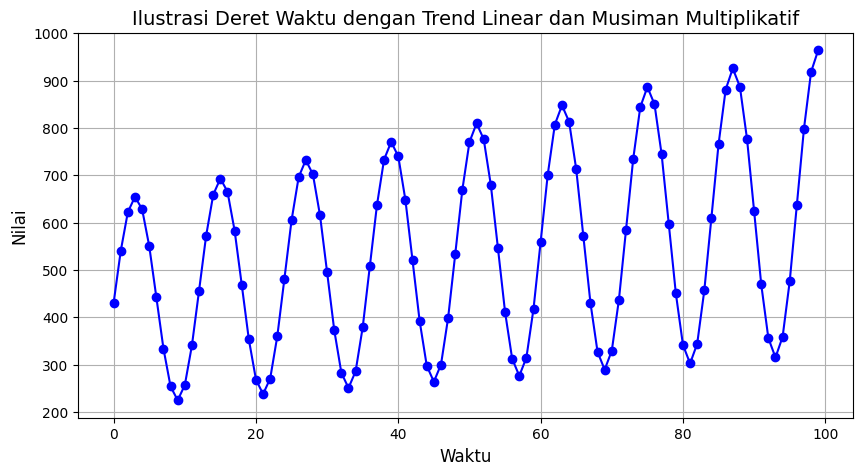

In [176]:
plt.figure(figsize=(10, 5))
plt.plot(x, series_multi, color='b', marker='o')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman Multiplikatif', fontsize=14)
plt.grid()
plt.show()

Berdasarkan ilustrasi yang dibuat, deret menunjukkan kecenderungan meningkat dari waktu ke waktu, tetapi peningkatan tersebut disertai fluktuasi musiman yang berulang. Berbeda dengan model aditif, pada model multiplikatif besarnya fluktuasi musiman bergantung pada tingkat nilai deret. Ketika nilai tren semakin tinggi, amplitudo atau besar naik-turun pola musiman juga semakin besar.

Dekomposisi dengan model multiplikatif hanya bisa dilakukan untuk deret dengan nilai >0, sehingga jika deret memiliki nilai 0 atau negatif maka deret perlu ditransformasi.

In [177]:
#  Dekomposisi dengan model multiplikatif
# mengubah data menjadi format dataframe
df_multi = pd.DataFrame(series_multi, columns=['Value'])

from statsmodels.tsa.seasonal import seasonal_decompose
result_multi = seasonal_decompose(df_multi['Value'], model='multiplicative', period=12)

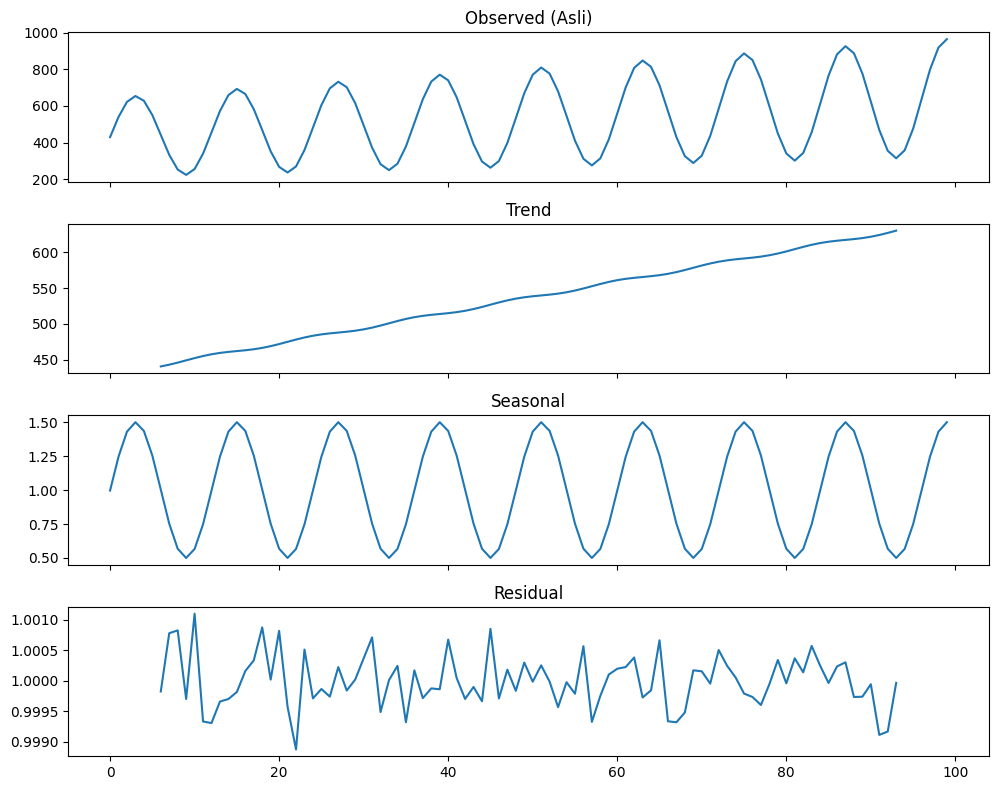

In [178]:
# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result_multi.observed.plot(ax=axes[0], title='Observed (Asli)')
result_multi.trend.plot(ax=axes[1], title='Trend')
result_multi.seasonal.plot(ax=axes[2], title='Seasonal')
result_multi.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Berdasarkan hasil dekomposisi deret waktu dengan model multiplikatif, interpretasinya dapat dijelaskan sebagai berikut.
- **Komponen observed (data asli)** menunjukkan adanya pola musiman yang berulang secara periodik. Selain itu, secara umum tingkat nilai deret juga mengalami kecenderungan meningkat seiring waktu. Fluktuasi naik dan turun terjadi secara berulang di sekitar kecenderungan jangka panjang tersebut.
- **Komponen trend** menunjukkan kecenderungan nilai deret yang terus meningkat dari waktu ke waktu. Hal ini mengindikasikan adanya tren jangka panjang yang positif, meskipun kenaikannya berlangsung secara bertahap.
- **Komponen seasonal** berfluktuasi di sekitar nilai 1, bukan di sekitar nol. Hal ini sesuai dengan karakteristik model dekomposisi multiplikatif. Nilai komponen musiman yang lebih besar dari 1 menunjukkan periode ketika musim meningkatkan nilai deret di atas tren, sedangkan nilai yang lebih kecil dari 1 menunjukkan periode ketika musim menurunkan nilai deret di bawah tren. Pola tersebut terlihat berulang secara konsisten setiap 12 periode.
- **Komponen residual** berfluktuasi di sekitar nilai 1 dengan variasi yang sangat kecil. Hal ini menunjukkan bahwa setelah pengaruh tren dan musiman dipisahkan, sebagian besar pola dalam data telah berhasil dijelaskan oleh kedua komponen tersebut. Sisa variasi yang tidak dapat dijelaskan oleh tren dan musiman relatif kecil dan tidak memperlihatkan pola sistematis yang jelas.

Maka dapat disimpulkan, hasil dekomposisi menunjukkan bahwa deret waktu memiliki tren meningkat dan pola musiman yang berulang setiap 12 periode. Karena menggunakan model multiplikatif, pengaruh musiman bekerja sebagai faktor pengali terhadap komponen tren, bukan sebagai tambahan konstan seperti pada model aditif. Dengan demikian, model multiplikatif sesuai digunakan untuk menggambarkan deret waktu ketika pola musiman dinyatakan secara proporsional terhadap tingkat atau nilai deret.


In [182]:
# Parameter
np.random.seed(1043)
n = 100  # Jumlah titik data
x = np.arange(n)

# Hanya noise acak tanpa trend atau musiman
noise = np.random.normal(loc=10, scale=2, size=n)  # Nilai acak sekitar 10

# Buat DataFrame untuk regresi
df = pd.DataFrame({'Time': x, 'Series': noise})
df['Time'] = pd.to_datetime(df['Time'], unit='D')  # Konversi ke format waktu
df.set_index('Time', inplace=True)

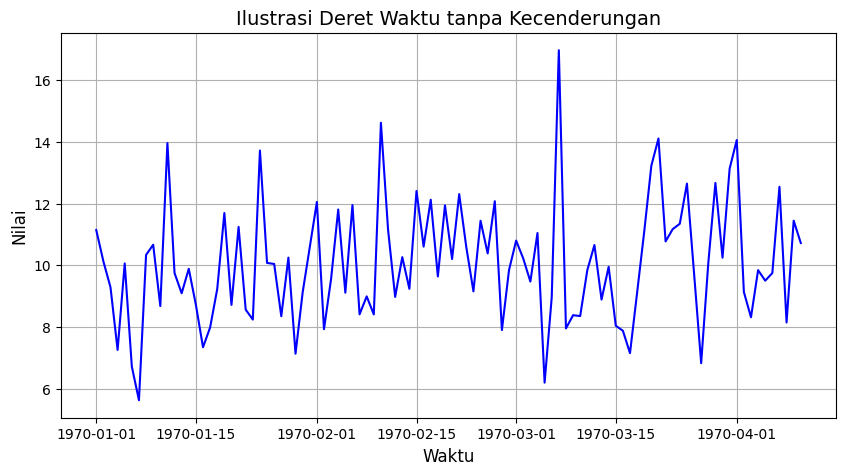

In [183]:
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Series'], color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu tanpa Kecenderungan', fontsize=14)
plt.grid()
plt.show()

Deret waktu tersebut berfluktuasi secara acak di sekitar nilai rata-ratanya tanpa menunjukkan pola peningkatan, penurunan, maupun pola musiman yang konsisten. Dengan demikian, deret ini dapat dikatakan tidak memiliki kecenderungan (tren) maupun pola musiman.

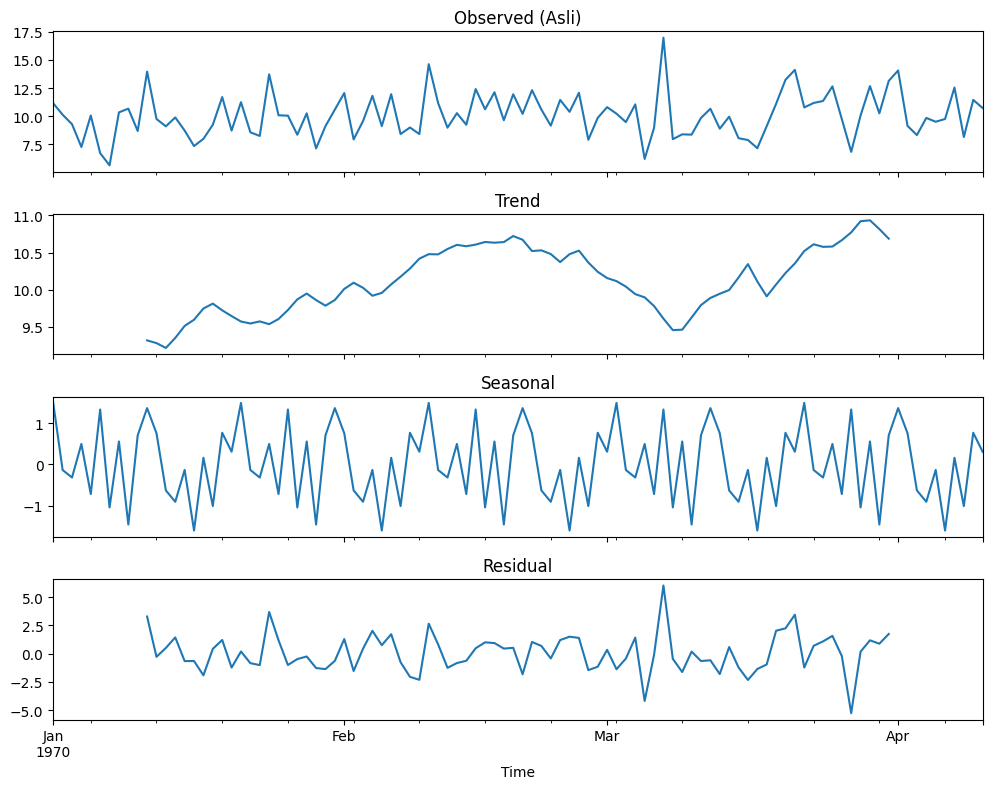

In [184]:
# Lakukan dekomposisi dengan model aditif
result = seasonal_decompose(df['Series'], model='additive', period=20)

# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana interpretasi dari plot tersebut?

Interpretasi plot dekomposisi tersebut adalah:
- **Komponen observed (data asli)** menunjukkan bahwa nilai deret waktu berfluktuasi dari waktu ke waktu tanpa pola kenaikan atau penurunan yang sangat tajam.
- **Komponen trend** menunjukkan adanya perubahan kecenderungan jangka panjang yang relatif kecil. Nilai trend sempat meningkat, kemudian menurun sekitar pertengahan periode, dan kembali meningkat pada akhir periode.
- **Komponen seasonal** menunjukkan adanya pola fluktuasi musiman di sekitar nol, tetapi pola tersebut relatif kecil dibandingkan variasi keseluruhan data.
Komponen residual masih menunjukkan fluktuasi acak dengan beberapa nilai yang cukup ekstrem. Hal ini menunjukkan bahwa terdapat variasi data yang tidak dapat dijelaskan sepenuhnya oleh komponen trend dan musiman.

Maka dapat disimpulkan, deret waktu ini tidak memiliki kecenderungan trend yang kuat, sedangkan pola musiman ada tetapi relatif kecil. Sebagian variasi deret masih berasal dari komponen acak atau residual.